# Venndicon Demo

Generate beautiful random Venn diagram SVG icons with Python!


In [ ]:
# Install the package (run once)
# !pip install -e .


In [1]:
from venndicon import Venndicon, generate


## Basic Usage

Create a random Venndicon - it renders inline in Jupyter!


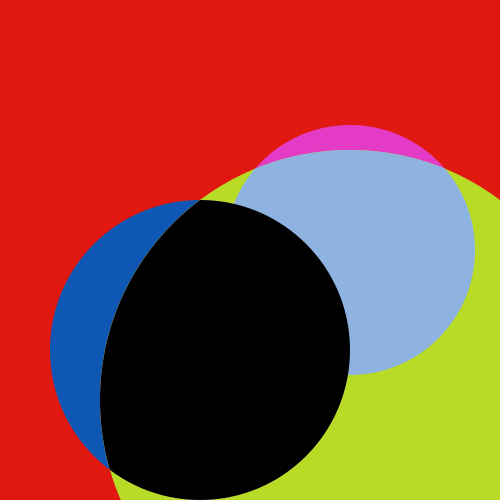

In [2]:
# Generate a random venndicon
icon = generate()
icon


## Reproducible Icons with Seeds

Use a seed to get the same icon every time:


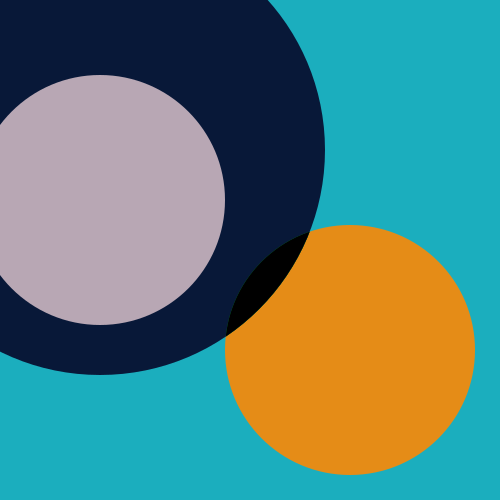

In [3]:
# Same seed = same icon
icon1 = generate(seed=42)
icon1


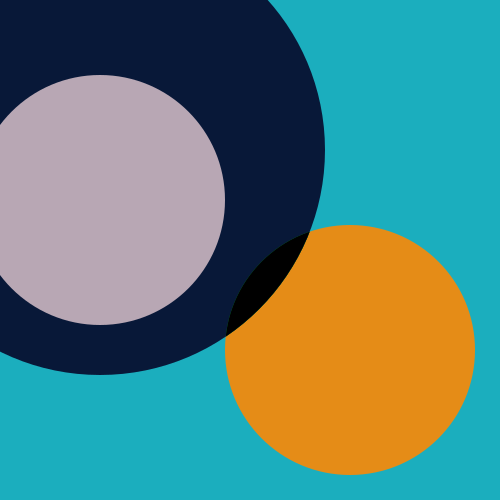

In [4]:
# Verify it's reproducible
icon2 = generate(seed=42)
icon2


## Custom Size

Create icons of different sizes:


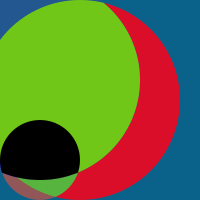

In [5]:
# Smaller icon
small = generate(size=200, seed=123)
small


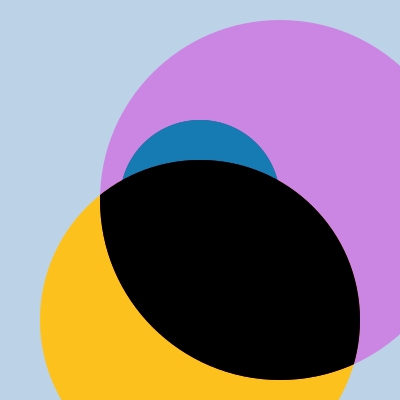

In [6]:
# Larger icon
large = generate(size=400, seed=456)
large


## Gallery of Random Icons

Generate multiple icons at once:


In [7]:
from IPython.display import display, HTML

# Generate a gallery of 6 icons
icons_html = '<div style="display: flex; flex-wrap: wrap; gap: 10px;">'
for seed in range(6):
    icon = generate(size=150, seed=seed * 100)
    icons_html += f'<div style="border: 1px solid #ccc; border-radius: 8px; overflow: hidden;">{icon.to_svg()}</div>'
icons_html += '</div>'

display(HTML(icons_html))


## Custom Colors

Provide your own color palette (8 colors for: background, circle1, circle2, circle3, intersection 1-2, intersection 1-3, intersection 2-3, all three):


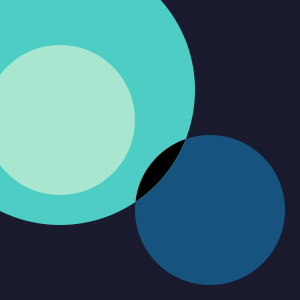

In [8]:
# Ocean theme
ocean_colors = [
    "#1a1a2e",  # background - deep navy
    "#16537e",  # circle 1 - ocean blue
    "#1e88a8",  # circle 2 - teal
    "#4ecdc4",  # circle 3 - aqua
    "#48c9b0",  # intersection 1-2
    "#73d0c2",  # intersection 1-3
    "#a8e6cf",  # intersection 2-3
    "#dfe6e9",  # center - foam white
]

ocean_icon = Venndicon(size=300, seed=42, colors=ocean_colors)
ocean_icon


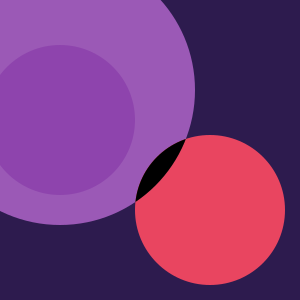

In [9]:
# Sunset theme
sunset_colors = [
    "#2d1b4e",  # background - dusk purple
    "#e94560",  # circle 1 - coral red
    "#f39c12",  # circle 2 - golden orange
    "#9b59b6",  # circle 3 - purple
    "#e67e22",  # intersection 1-2 - orange
    "#c0392b",  # intersection 1-3 - crimson
    "#8e44ad",  # intersection 2-3 - violet
    "#f5f5f5",  # center - bright
]

sunset_icon = Venndicon(size=300, seed=42, colors=sunset_colors)
sunset_icon


## Save to File


Saved to my_venndicon.svg!


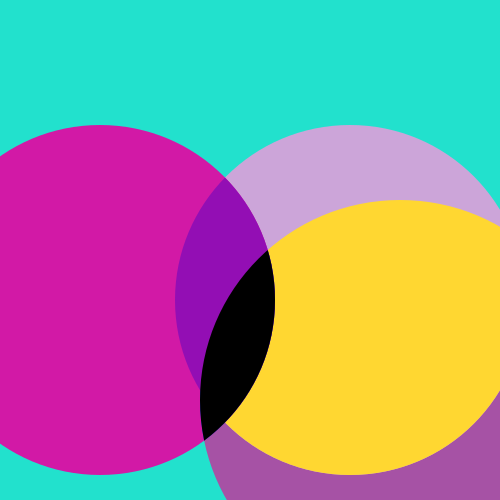

In [10]:
# Save an icon to a file
icon = generate(seed=999)
icon.save("my_venndicon.svg")
print("Saved to my_venndicon.svg!")
icon


## Access SVG as String


In [11]:
# Get the raw SVG string
svg_string = generate(size=100, seed=1).to_svg()
print(svg_string[:500] + "...")


<svg baseProfile="full" height="100" version="1.1" width="100" xmlns="http://www.w3.org/2000/svg" xmlns:ev="http://www.w3.org/2001/xml-events" xmlns:xlink="http://www.w3.org/1999/xlink"><defs><clipPath id="clip2_a8d6eee8"><circle cx="60" cy="80" r="20.0" /></clipPath><clipPath id="clip3_a8d6eee8"><circle cx="80" cy="20" r="35.0" /></clipPath><clipPath id="clip3a_a8d6eee8"><circle cx="80" cy="20" r="35.0" /></clipPath><clipPath id="clip1_a8d6eee8"><circle cx="30" cy="80" r="30.0" /></clipPath><cl...


## Inspect Icon Properties


In [12]:
icon = generate(seed=42)

print(f"Size: {icon.size}px")
print(f"Circle 1: center=({icon.cx1}, {icon.cy1}), radius={icon.cr1}")
print(f"Circle 2: center=({icon.cx2}, {icon.cy2}), radius={icon.cr2}")
print(f"Circle 3: center=({icon.cx3}, {icon.cy3}), radius={icon.cr3}")
print(f"\nColors:")
print(f"  Background: {icon.background_color}")
print(f"  Circle 1: {icon.circle1_color}")
print(f"  Circle 2: {icon.circle2_color}")
print(f"  Circle 3: {icon.circle3_color}")
print(f"  1∩2: {icon.intersection12_color}")
print(f"  1∩3: {icon.intersection13_color}")
print(f"  2∩3: {icon.intersection23_color}")
print(f"  1∩2∩3: {icon.intersection123_color}")


Size: 500px
Circle 1: center=(350, 350), radius=250
Circle 2: center=(100, 200), radius=250
Circle 3: center=(100, 150), radius=450

Colors:
  Background: #1baebe
  Circle 1: #e58c17
  Circle 2: #986d09
  Circle 3: #081838
  1∩2: #3c829b
  1∩3: #079033
  2∩3: #b8a7b4
  1∩2∩3: #8c6c39


## Generate a Grid of Icons

Create grids of Venndicons with arbitrary dimensions:


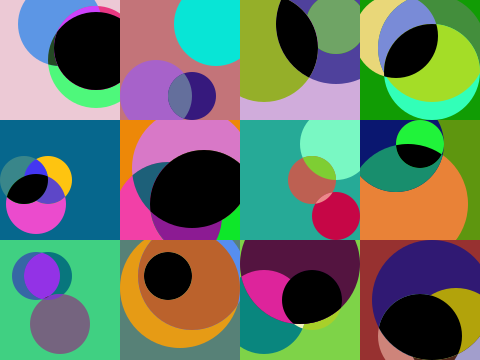

In [13]:
from venndicon import grid

# Create a 3x4 grid of icons
g = grid(rows=3, cols=4, cell_size=120, gap=8, start_seed=0)
g


Grid size: 530x215 pixels


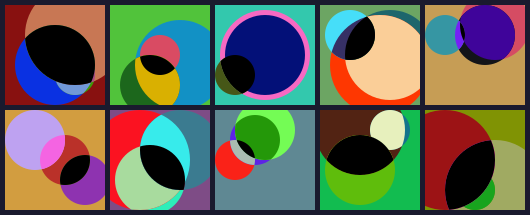

In [14]:
# Create a larger grid with random seeds
g2 = grid(rows=2, cols=5, cell_size=100, gap=5, background="#1a1a2e")
print(f"Grid size: {g2.width}x{g2.height} pixels")
g2


## Export as PNG or JPEG

Save icons as raster images (requires `pip install cairosvg Pillow`):


In [15]:
# Save as PNG
icon = generate(seed=42)
icon.save_png("icon.png")
icon.save_png("icon_2x.png", scale=2.0)  # 2x resolution

# Save as JPEG
icon.save_jpeg("icon.jpg", quality=95)

# Grids too!
g = grid(rows=2, cols=3, cell_size=100, start_seed=0)
g.save_jpeg("grid.jpg", quality=90)

print("Saved: icon.png, icon_2x.png, icon.jpg, grid.jpg")


Saved: icon.png, icon_2x.png, icon.jpg, grid.jpg


## Analyze Image Quadrants

Calculate average RGB colors for each quadrant of any square image:


In [16]:
from venndicon import analyze_quadrants

# Analyze a Venndicon directly
icon = generate(seed=42, size=200)
colors = analyze_quadrants(icon)

print("Quadrant RGB values:")
print(f"  Top-left:     {colors.top_left}")
print(f"  Top-right:    {colors.top_right}")
print(f"  Bottom-left:  {colors.bottom_left}")
print(f"  Bottom-right: {colors.bottom_right}")

print("\nAs hex colors:")
for name, hex_color in colors.to_hex().items():
    print(f"  {name}: {hex_color}")


Quadrant RGB values:
  Top-left:     (105, 103, 124)
  Top-right:    (30, 136, 151)
  Bottom-left:  (59, 134, 149)
  Bottom-right: (163, 146, 71)

As hex colors:
  top_left: #69677c
  top_right: #1e8897
  bottom_left: #3b8695
  bottom_right: #a39247


In [17]:
# Also works with file paths (JPEG, PNG, or SVG)
# colors = analyze_quadrants("my_image.jpg")
# colors = analyze_quadrants("icon.svg")

# Or with grids
g = grid(rows=2, cols=2, cell_size=100, start_seed=0)
grid_colors = analyze_quadrants(g)
print("Grid quadrant colors:")
print(grid_colors.to_hex())


Grid quadrant colors:
{'top_left': '#666b73', 'top_right': '#666f84', 'bottom_left': '#686d55', 'bottom_right': '#518540'}


## Analyze Any Image as a Grid

Divide any image into a grid of squares and analyze each cell's quadrant colors:


In [18]:
from venndicon import analyze_image_grid

# Analyze an image as a 5x5 grid
# The image is automatically cropped/centered to fit the grid
result = analyze_image_grid("ben.jpg", cols=100, rows=100)
print(result)
print(f"Each cell is {result.cell_size}x{result.cell_size} pixels\n")

# Access individual cells
cell = result.get(col=2, row=2)  # Center cell
print(f"Center cell quadrants: {cell.to_hex()}")


ImageGridAnalysis(cols=100, rows=100, cell_size=5px, total_cells=10000)
Each cell is 5x5 pixels

Center cell quadrants: {'top_left': '#ffffff', 'top_right': '#ffffff', 'bottom_left': '#ffffff', 'bottom_right': '#ffffff'}


In [19]:
# Visualize the grid - print hex colors for each cell
print("Grid of top-left quadrant colors:")
for row in range(result.rows):
    row_colors = [result.get(col, row).to_hex()['top_left'] for col in range(result.cols)]
    print(" ".join(row_colors))


Grid of top-left quadrant colors:
#ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #fefefe #fefefe #fefdfe #fefefe #fdfdfd #fcfcfc #fefefc #fefefc #fefffd #fefefe #fefefe #fefefe #fefefc #f2eee8 #a4968e #9b8c83 #ab998f #d9cec2 #f6f2ee #fdfdfd #fffffd #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff
#ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #ffffff #fffff

## Match Venndicons to an Image

Use the Hungarian algorithm to find the optimal arrangement of Venndicons that best matches an image's colors:


In [26]:
from venndicon import match_venndicons_to_image
from IPython.display import display, HTML
from PIL import Image
import base64
import io

# Settings
COLS, ROWS = 60, 60
CELL_SIZE = 10
START_SEED = 0

# Match venndicons to the image using image color palette (default)
# use_image_colors=True samples venndicon colors from the image's color distribution
result = match_venndicons_to_image(
    "dad.jpg",
    cols=COLS, rows=ROWS,
    start_seed=START_SEED,
    cell_size=CELL_SIZE,
    use_image_colors=True,  # Colors sampled from image palette
)


In [27]:

# Get both grids - they contain the EXACT SAME venndicons, just in different order
original_grid = result.original_grid(gap=0)  # Original seed order
matched_grid = result.to_grid(gap=0)          # Optimized arrangement

print(f"Grid: {COLS}x{ROWS} = {COLS*ROWS} venndicons")
print(f"Result: {result}")
print(f"Total squared color distance: {result.total_distance:,.0f}")
print(f"\nNote: use_image_colors=True makes venndicon colors match the image palette")


Grid: 60x60 = 3600 venndicons
Result: MatchedGrid(cols=60, rows=60, total_distance=52621753)
Total squared color distance: 52,621,753

Note: use_image_colors=True makes venndicon colors match the image palette


In [ ]:
# Display side-by-side: Original Image | Original Grid | Matched Grid

# Get the display size (match the grid dimensions)
gap = 3
display_size = COLS * CELL_SIZE + (COLS + 1) * gap

# Load and resize original image to match grid size
img = Image.open("ben.jpg")
img_resized = img.resize((display_size, display_size))
img_buffer = io.BytesIO()
img_resized.save(img_buffer, format="JPEG", quality=95)
img_b64 = base64.b64encode(img_buffer.getvalue()).decode()

# Get SVG strings
original_svg = original_grid.to_svg()
matched_svg = matched_grid.to_svg()

html = f'''
<div style="display: flex; gap: 20px; align-items: flex-start; background: #1a1a1a; padding: 20px; border-radius: 10px;">
    <div style="text-align: center;">
        <div style="color: #aaa; margin-bottom: 8px; font-family: sans-serif; font-size: 14px;">Original Image</div>
        <img src="data:image/jpeg;base64,{img_b64}" style="border-radius: 5px;">
    </div>
    <div style="text-align: center;">
        <div style="color: #aaa; margin-bottom: 8px; font-family: sans-serif; font-size: 14px;">Original Grid (seed order)</div>
        <div style="border-radius: 5px; overflow: hidden;">{original_svg}</div>
    </div>
    <div style="text-align: center;">
        <div style="color: #aaa; margin-bottom: 8px; font-family: sans-serif; font-size: 14px;">Matched Grid (optimized)</div>
        <div style="border-radius: 5px; overflow: hidden;">{matched_svg}</div>
    </div>
</div>
'''
display(HTML(html))
